#**CHOCOLATE SALES ANALYSIS**

#Business Understanding

##Latar Belakang
Perusahaan ingin memahami performa penjualan produk cokelat guna meningkatkan revenue dan profit.

##Tujuan Analisis


*   Mengidentifikasi produk terlaris
*   Mengetahui performa store


*   Menganalisis profitabilitas
*   Memberikan rekomendasi bisnis

##Pertanyaan Bisnis


1.   Produk mana yang menghasilkan revenue terbesar?
2.   Store mana yang paling perform?
3.   Bagaimana tren penjualan dari waktu ke waktu?
4.   Seberapa besar profit yang dihasilkan?






#Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_columns', None)

#Load Data

In [ ]:
sales = pd.read_csv('sales.csv')
products = pd.read_csv('products.csv')
customers = pd.read_csv('customers.csv')
stores = pd.read_csv('stores.csv')
calendar = pd.read_csv('calendar.csv')

print("Sales shape:", sales.shape)
print("Products shape:", products.shape)
print("Customers shape:", customers.shape)
print("Stores shape:", stores.shape)
print("Calendar shape:", calendar.shape)

Sales shape: (1000000, 11)
Products shape: (200, 6)
Customers shape: (50000, 5)
Stores shape: (100, 5)
Calendar shape: (731, 6)


#Data Understanding

In [ ]:
print("\n===== SALES INFO =====")
print(sales.info())
print(sales.head())

print("\n===== MISSING VALUE =====")
print(sales.isna().sum())


===== SALES INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB
None
      order_id  order_date product_id store_id customer_id  quantity  \
0  0RD00000001  2023-01-07      P0080     S093     C040749         5   
1  0RD00000002  2023-10-22      P0173     S065     C020161         3   
2  0RD00

#Data Cleaning

In [ ]:
#Hapus data duplikat
sales.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
stores.drop_duplicates(inplace=True)
calendar.drop_duplicates(inplace=True)

#konversi date
sales['order_date'] = pd.to_datetime(sales['order_date'])
calendar['date'] = pd.to_datetime(calendar['date'])

#cek missing values
print("\nMissing values after cleaning:")
print(sales.isnull().sum())


Missing values after cleaning:
order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64


#Data Merging

In [ ]:
df = sales.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(stores, on='store_id', how='left')
df = df.merge(calendar, left_on='order_date', right_on='date', how='left')

print("\nMerged Dataset Shape:", df.shape)
print(df.head())


Merged Dataset Shape: (1000000, 30)
      order_id order_date product_id store_id customer_id  quantity  \
0  0RD00000001 2023-01-07      P0080     S093     C040749         5   
1  0RD00000002 2023-10-22      P0173     S065     C020161         3   
2  0RD00000003 2023-05-07      P0115     S078     C048069         2   
3  0RD00000004 2024-06-23      P0186     S088     C047901         2   
4  0RD00000005 2024-09-24      P0197     S054     C033950         1   

   unit_price  discount  revenue   cost  profit           product_name  \
0       14.43      0.15    61.33  42.77   18.56  Praline Chocolate 70%   
1       12.01      0.00    36.03  19.06   16.97     Dark Chocolate 60%   
2       10.02      0.00    20.04  10.29    9.75     Milk Chocolate 90%   
3       14.66      0.10    26.39  16.35   10.04     Dark Chocolate 60%   
4       12.34      0.00    12.34   7.94    4.40  Truffle Chocolate 90%   

     brand category  cocoa_percent  weight_g  age  gender  loyalty_member  \
0  Hershey    

#Feature Enginerering
##1. Profit Margin

In [ ]:
df['profit_margin'] = (df['profit']/df['revenue']) * 100

##2. KPI Analysis

In [ ]:
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
avg_margin = df['profit_margin'].mean()

print("\n===== KPI ANALYSIS =====")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Margin: {avg_margin:.2f}%")


===== KPI ANALYSIS =====
Total Revenue: 25,486,128.86
Total Profit: 10,194,564.63
Total Orders: 1,000,000
Average Margin: 40.00%


##3. Top Products Analysis


===== TOP PRODUCTS =====
product_name
Dark Chocolate 50%       1775041.34
Truffle Chocolate 80%    1643258.83
Milk Chocolate 70%       1384758.27
Praline Chocolate 50%    1382597.04
Dark Chocolate 60%       1272649.97
White Chocolate 50%      1265949.75
White Chocolate 90%      1137968.57
White Chocolate 80%      1133285.39
Truffle Chocolate 90%    1132883.80
Praline Chocolate 70%    1127404.94
Name: revenue, dtype: float64


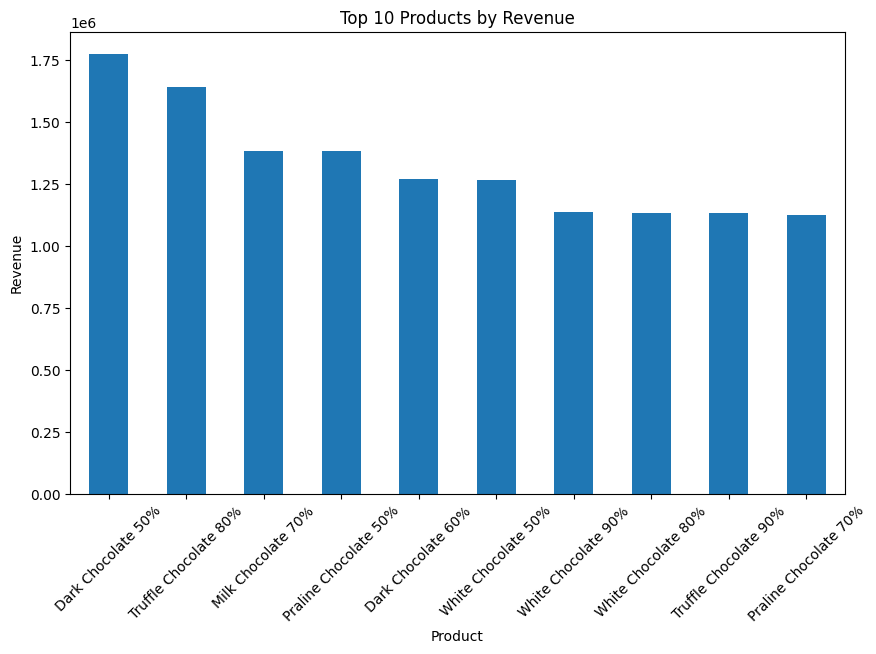

In [ ]:
top_products = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)
print("\n===== TOP PRODUCTS =====")
print(top_products)

#plot
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

###Insight:
Produk dengan revenue tertinggi merupakan kontributor utama dalam bisnis. Fokus pada produk-produk diatas dapat meningkatkan penjualan.

##4. Store Performance

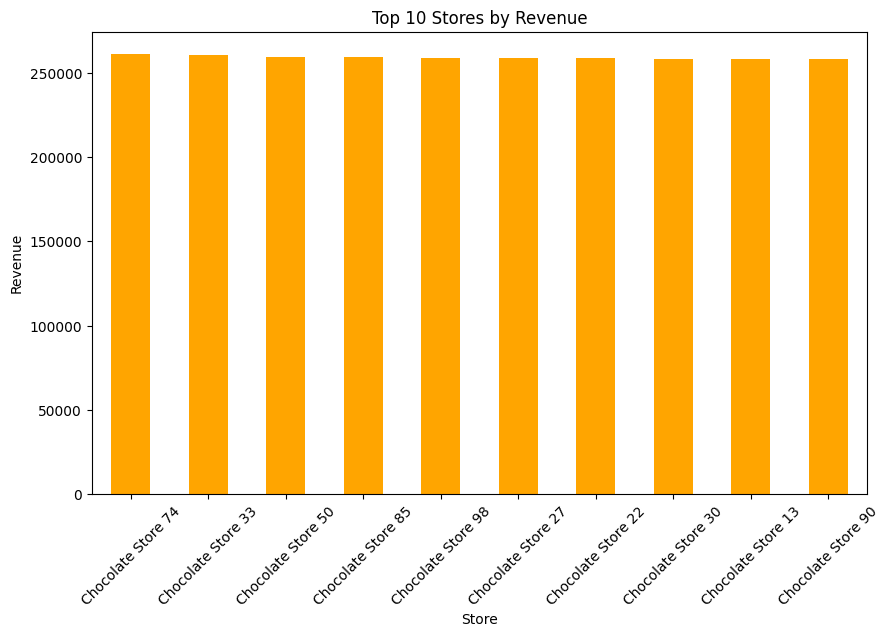

In [ ]:
top_stores = df.groupby('store_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_stores.plot(kind='bar', color='orange')
plt.title("Top 10 Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

###Insight:
Performa antar store relatif merata, menandakan distribusi bisnis yang sehat.

##5. Sales Trend Analysis

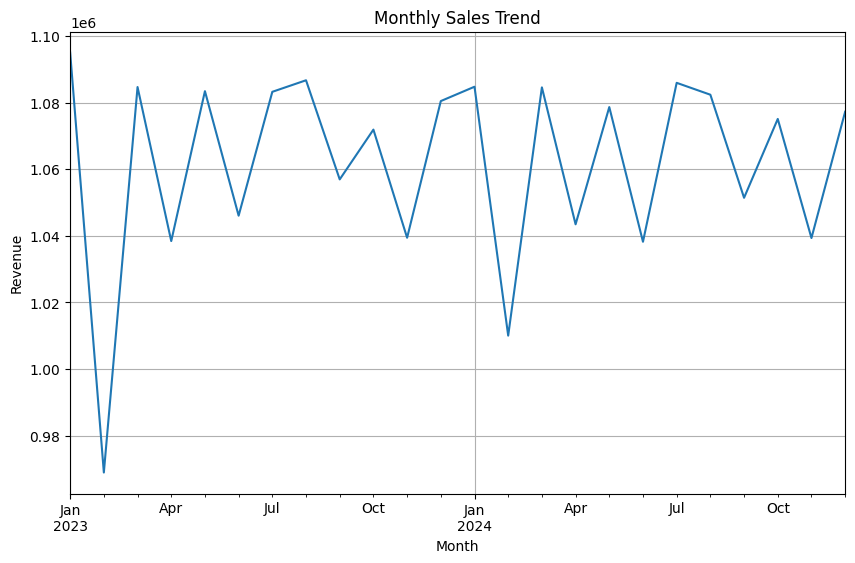

In [ ]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()

plt.figure(figsize=(10,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

###Insight:
Tren penjualan membantu melihat pola musiman atau pertumbuhan bisnis.

##6. Customer Analysis

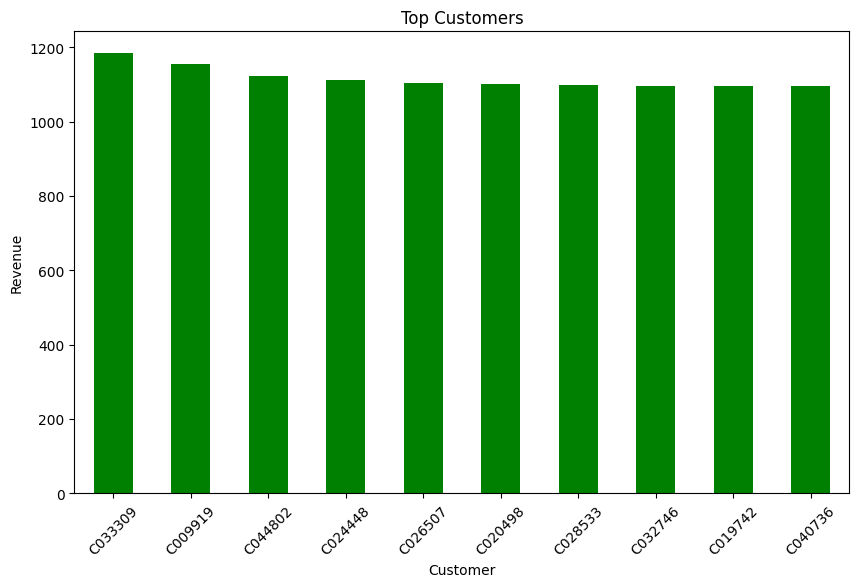

In [ ]:
top_customers = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_customers.plot(kind='bar', color='green')
plt.title("Top Customers")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

###Insight:
Customer dengan kontribusi tinggi bisa menjadi target program loyalty.

##6. Category Analysis

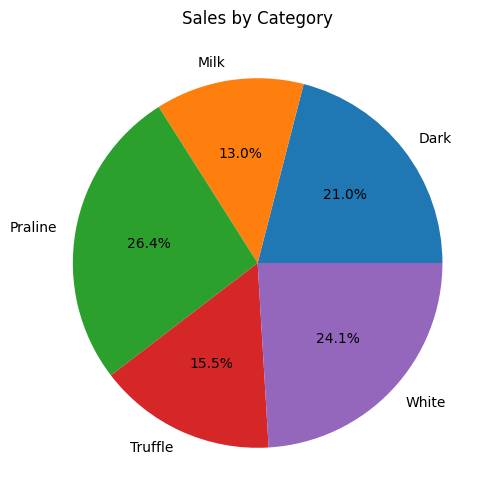

In [ ]:
category_sales = df.groupby('category')['revenue'].sum()

plt.figure(figsize=(10,6))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.ylabel("")
plt.show()

###Insight:
Produk dengan kategori Praline menjadi produk dengan kontribusi revenue tertinggi, sebanyak 26.4% dari total revenue. Prioritaskan produk dengan kontribusi revenue di atas 20% untuk meningkatkan revenue.

##7. Profit Analysis

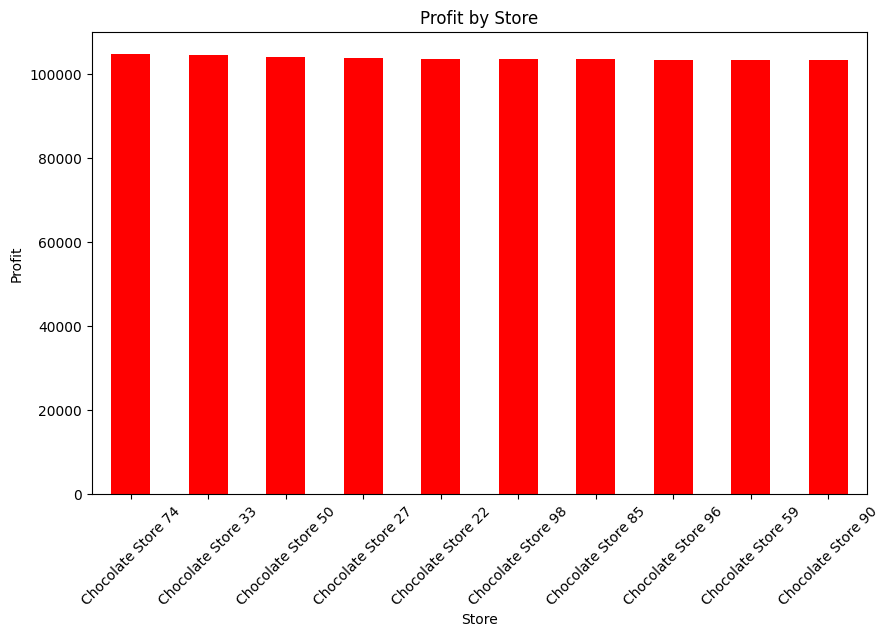

In [ ]:
profit_store = df.groupby('store_name')['profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
profit_store.plot(kind='bar', color='red')
plt.title("Profit by Store")
plt.xlabel("Store")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

###Insight:
Tidak semua store dengan revenue tertinggi menghasilkan profit tertinggi. Perlu dilakukan efisiensi biaya.

##Key Insight



*   Profit margin cukup tinggi (~40%)
*   Produk premium mendominasi revenue


*   Distribusi penjualan cukup merata

##Recommendations


1.   Fokus pada produk best seller
2.   Tingkatkan performa store yang lemah
3.   Kembangkan program loyalitas pelanggan







